In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
bom0 = cv2.imread('Assets/Meledak.png')
kembang0 = cv2.imread('Assets/Bunga.png')
sora0 = cv2.imread('Assets/Langit.png')
yucuber0 = cv2.imread('Assets/Windut.png')

Text(0.5, 1.0, 'citra bom')

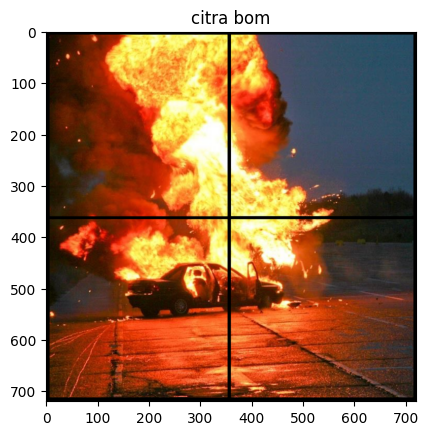

In [5]:
bom = cv2.cvtColor(bom0, cv2.COLOR_BGR2RGB)
sora = cv2.cvtColor(sora0, cv2.COLOR_BGR2RGB)
kembang = cv2.cvtColor(kembang0, cv2.COLOR_BGR2RGB)
yucuber = cv2.cvtColor(yucuber0, cv2.COLOR_BGR2RGB)

plt.imshow(bom)
plt.title('citra bom')

Text(0.5, 1.0, 'part4')

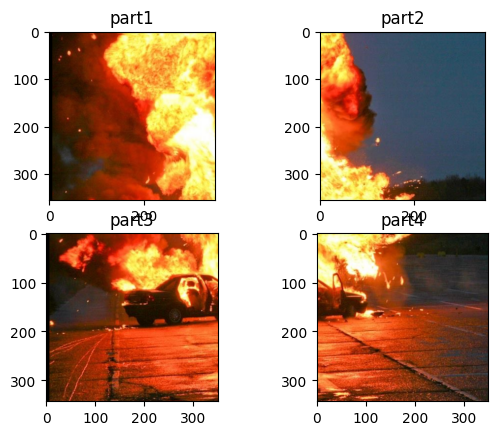

In [6]:
bom1 = bom[5:360, 0:350]
plt.subplot (2, 2, 1)
plt.imshow(bom1)
plt.title("part1")

bom2 = bom[5:360, 360:710]
plt.subplot (2, 2, 2)
plt.imshow(bom2)
plt.title("part2")

bom3 = bom[367:710, 0:350]
plt.subplot (2, 2, 3)
plt.imshow(bom3)
plt.title("part3")

bom4 = bom[367:710, 360:710]
plt.subplot (2, 2, 4)
plt.imshow(bom4)
plt.title("part4")

In [7]:
def merge_image(citra1, citra2, orientation='H'):
    if orientation == 'H':
        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]

        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype)
            gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
            gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2
    else:
        tinggi_total = citra1.shape[0] + citra2.shape[0]
        lebar = max(citra1.shape[1], citra2.shape[1])

        if len(citra1.shape) == 2:
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype)
        else:
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype)

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2

    return gabungan


Text(0.5, 1.0, 'Merge')

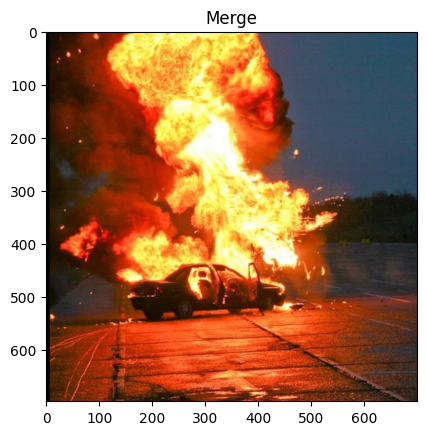

In [8]:
bomJadi1 = merge_image(bom1, bom2, 'H')
bomJadi2 = merge_image(bom3, bom4, 'H')
bomJadi3 = merge_image(bomJadi1, bomJadi2, 'V')

plt.imshow(bomJadi3)
plt.title('Merge')

Text(0.5, 1.0, 'grayscale')

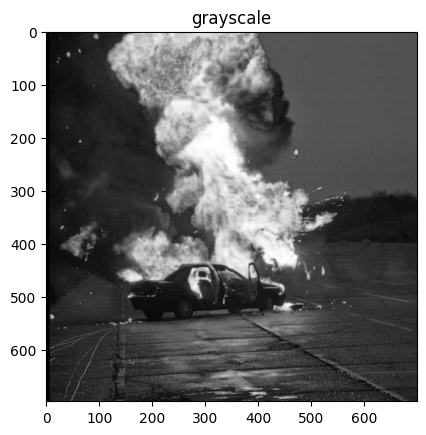

In [9]:
bom_gray = cv2.cvtColor(bomJadi3, cv2.COLOR_BGR2GRAY)

plt.imshow(bom_gray, cmap='gray')
plt.title('grayscale')

Text(0.5, 1.0, 'Ekualisasi')

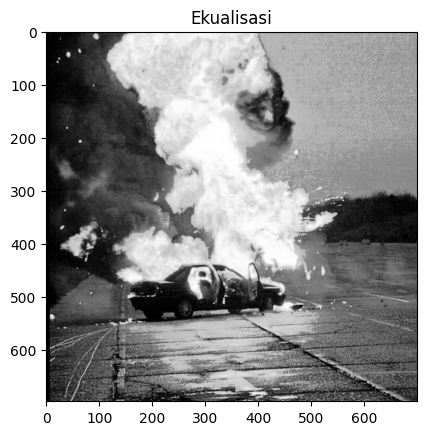

In [10]:
def equalization(image):
    e_hist = np.zeros(256, dtype=int)
    height, width = image.shape

    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            e_hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(e_hist[0:i+1])

    result = np.round((cdf * 255) / (height * width)).astype(np.uint8)

    result2 = np.zeros(image.shape, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            result2[i, j] = result[val]

    return result2



ekualisasiBom = equalization(bom_gray)
plt.imshow(ekualisasiBom, cmap='gray')
plt.title('Ekualisasi')

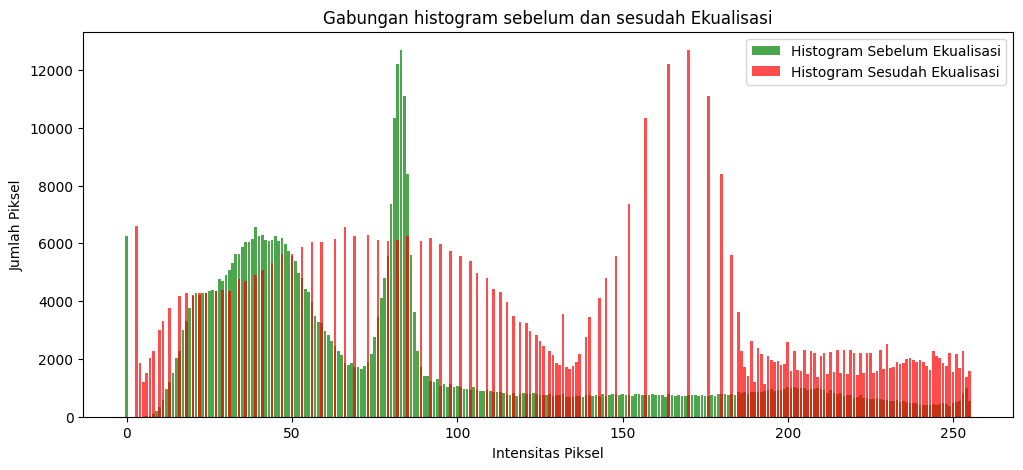

In [11]:
def buat_hist(citra):
    histogram = [0] * 256
    height = len(citra)
    width = len(citra[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1
    return histogram

histSebelum = buat_hist(bom_gray)
histSesudah = buat_hist(ekualisasiBom)

plt.figure(figsize=(12, 5))
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.bar(range(256), histSebelum, color='green', label='Histogram Sebelum Ekualisasi', alpha=0.7)
plt.bar(range(256), histSesudah, color='red',   label='Histogram Sesudah Ekualisasi', alpha=0.7)
plt.title('Gabungan histogram sebelum dan sesudah Ekualisasi')
plt.legend()

Text(0.5, 1.0, 'Bunga ireng')

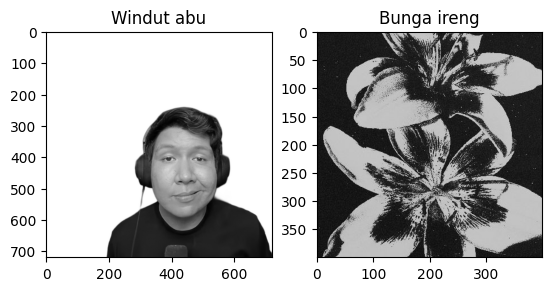

In [12]:
yucuber_gray = cv2.cvtColor(yucuber, cv2.COLOR_BGR2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(yucuber_gray, cmap='gray')
plt.title('Windut abu')
plt.subplot(1, 2, 2)
plt.imshow(kembang)
plt.title('Bunga ireng')

Text(0.5, 1.0, 'Hasil spesifikasi')

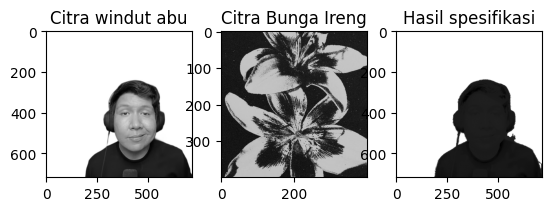

In [13]:
def spesifikasi_histogram(source, target):
    height, width = source.shape

    # Hitung histogram source
    hist_source = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            hist_source[source[i, j]] += 1
    cdf_source = np.cumsum(hist_source)
    cdf_source = np.round(cdf_source * 255 / cdf_source[-1]).astype(np.uint8)

    # Hitung histogram target
    hist_target = np.zeros(256, dtype=int)
    for i in range(target.shape[0]):
        for j in range(target.shape[1]):
            hist_target[target[i, j]] += 1
    cdf_target = np.cumsum(hist_target)
    cdf_target = np.round(cdf_target * 255 / cdf_target[-1]).astype(np.uint8)

    # Buat mapping dari CDF source ke CDF target
    mapping = np.zeros(256, dtype=np.uint8)
    for source_val in range(256):
        diff = np.abs(cdf_source[source_val].astype(int) - cdf_target.astype(int))
        mapping[source_val] = np.argmin(diff)

    # Terapkan mapping ke gambar source
    result = np.zeros_like(source)
    for i in range(height):
        for j in range(width):
            result[i, j] = mapping[source[i, j]]

    return result

kembang_gray = cv2.cvtColor(kembang, cv2.COLOR_BGR2GRAY)
spesifikasi1 = spesifikasi_histogram(yucuber_gray, kembang_gray)

plt.subplot(1, 3, 1)
plt.imshow(yucuber_gray, cmap='gray')
plt.title('Citra windut abu')
plt.subplot(1, 3, 2)
plt.imshow(kembang, cmap='gray')
plt.title('Citra Bunga Ireng')
plt.subplot(1, 3, 3)
plt.imshow(spesifikasi1, cmap='gray')
plt.title('Hasil spesifikasi')

Text(0.5, 1.0, 'Spesifikasi windut dengan bunga')

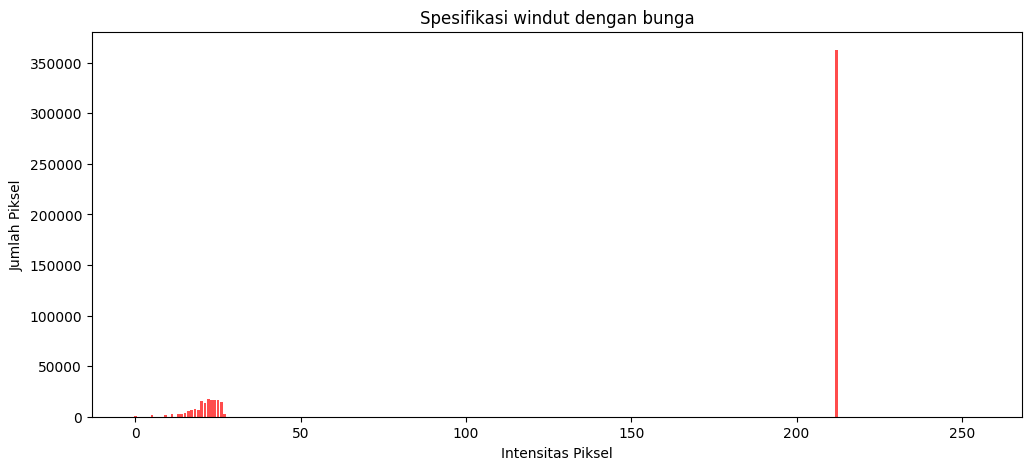

In [14]:
hist3 = buat_hist(spesifikasi1)

plt.figure(figsize=(12, 5))
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.bar(range(256), hist3, color='red', alpha=0.7)
plt.title('Spesifikasi windut dengan bunga')

In [15]:
print(spesifikasi1.shape)
print(ekualisasiBom.shape)

(720, 720)
(698, 700)


In [16]:
cropBom = spesifikasi1[0:698, 0:700]
print(cropBom.shape)
print(ekualisasiBom.shape)

(698, 700)
(698, 700)


Text(0.5, 1.0, 'Windut hitam')

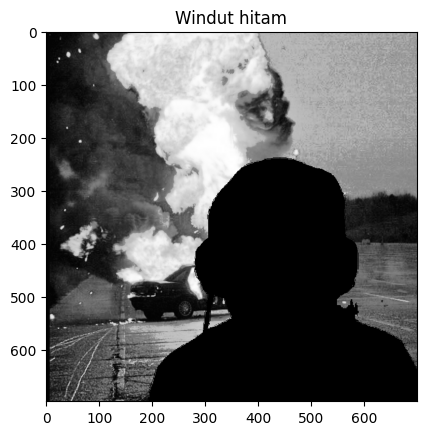

In [17]:
def gabung(imageAwal, imageGabung):
    h, w = imageAwal.shape
    hasil_gabung = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            if imageAwal[i, j] > 200:
                hasil_gabung[i, j] = imageGabung[i, j]
            else:
                hasil_gabung[i, j] = 0
    return hasil_gabung

hasil_gabung = gabung(cropBom, ekualisasiBom)
plt.imshow(hasil_gabung, cmap='gray')
plt.title('Windut hitam')

Text(0.5, 1.0, 'Windut akhir zaman')

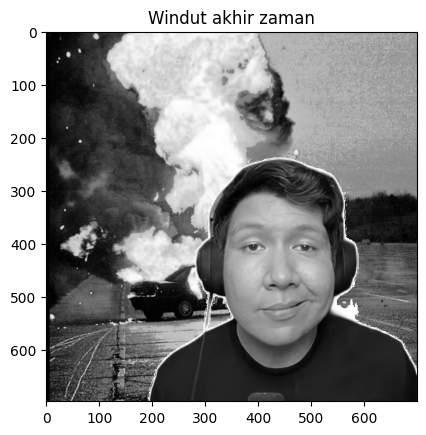

In [18]:
cropAkhir = yucuber_gray[0:698, 0:700]
windutAkhir = hasil_gabung + cropAkhir

plt.imshow(windutAkhir, cmap='gray')
plt.title('Windut akhir zaman')

Text(0.5, 1.0, 'Citra windut akhir zaman')

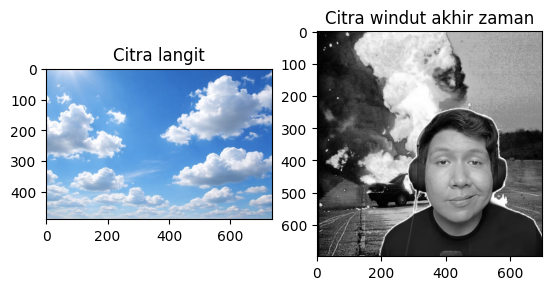

In [19]:
plt.subplot(1, 2, 1)
plt.imshow(sora)
plt.title('Citra langit')
plt.subplot(1, 2, 2)
plt.imshow(windutAkhir, cmap='gray')
plt.title('Citra windut akhir zaman')

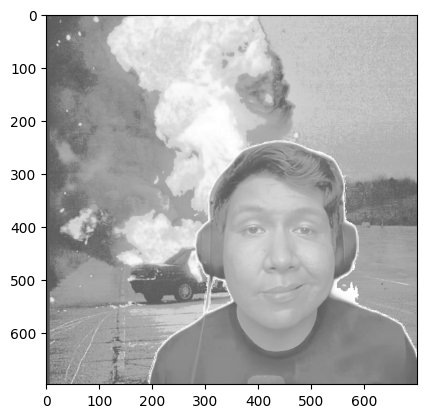

In [20]:
sora_gray = cv2.cvtColor(sora, cv2.COLOR_RGB2GRAY)

spesifikasi2 = spesifikasi_histogram(windutAkhir, sora_gray)
plt.imshow(spesifikasi2, cmap='gray')

Text(0.5, 1.0, 'windut akhir')

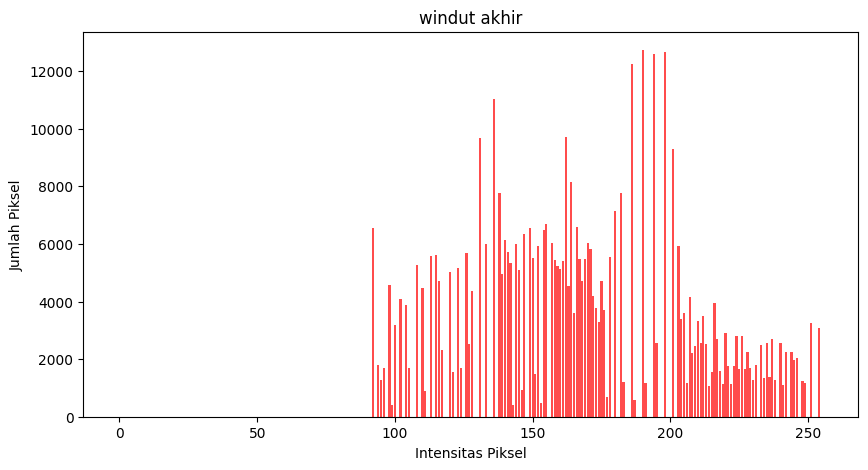

In [21]:
hist4 = buat_hist(spesifikasi2)

plt.figure(figsize=(10, 5))
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.bar(range(256), hist4, color='red', alpha=0.7)
plt.title('windut akhir')

Text(0.5, 1.0, 'bom baru')

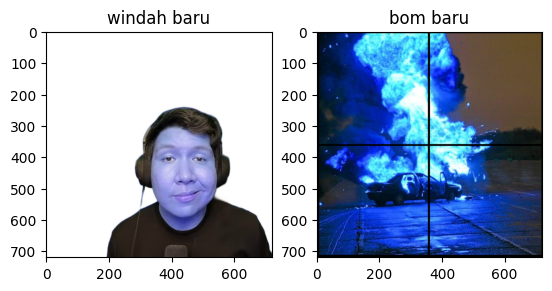

In [25]:
windah_baru = cv2.imread("Assets/Windut.png")
bom_baru = cv2.imread("Assets/Meledak.png")
plt.subplot(1, 2, 1)
plt.imshow(windah_baru)
plt.title('windah baru')
plt.subplot(1, 2, 2)
plt.imshow(bom_baru)
plt.title('bom baru')

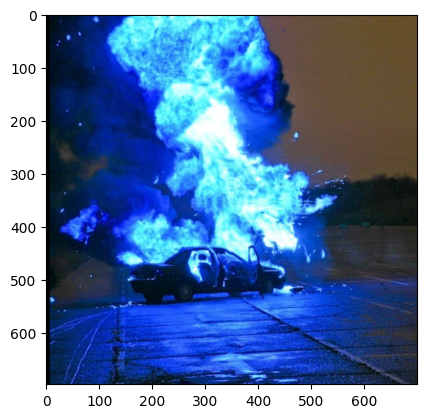

In [27]:
bomBaru1 = bom_baru[5:360, 0:350]
bomBaru2 = bom_baru[5:360, 360:710]
bomBaru3 = bom_baru[367:710, 0:350]
bomBaru4 = bom_baru[367:710, 360:710]

baruMerge1 = merge_image(bomBaru1, bomBaru2, 'H')
baruMerge2 = merge_image(bomBaru3, bomBaru4, 'H')
baruMerge3 = merge_image(baruMerge1, baruMerge2, 'v')

plt.imshow(baruMerge3)

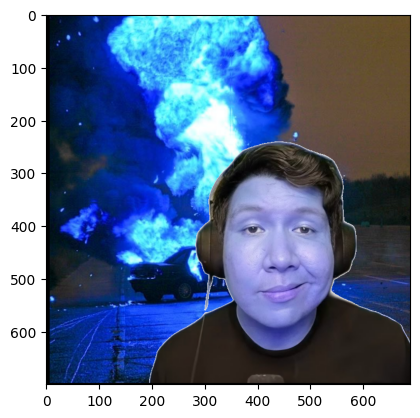

In [32]:
hasil = np.zeros_like(windah_baru, dtype=int)


for i in range(baruMerge3.shape[0]):
    for j in range(baruMerge3.shape[1]):
        if windah_baru[i, j, 0] > 230:
            hasil[i, j] = baruMerge3[i, j]
        else:
            hasil[i,j] = windah_baru[i, j]
            

# 3. Tampilkan hasil
hasil = hasil[0:700, 0: 690]
plt.imshow(hasil, cmap="gray")
plt.show()